In [18]:
%matplotlib inline

In [19]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
#PROJECT_DIR_CUSTOM_SUPER = "simulation_wavefield_custom_stf_weighted_super"
PROJECT_DIR_CUSTOM_SUPER = "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20_simple"
PROJECT_DIR_CUSTOM_SUB = "simulation_wavefield_custom_stf_weighted_sub"



import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

In [20]:
# Setup of the model domain as a box 
domain_2d_mpm = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400.0, y0=0, y1=3)

p_sub = sn.Project.from_domain(path=PROJECT_DIR_CUSTOM_SUB, domain=domain_2d_mpm, load_if_exists=True)
p_super = sn.Project.from_domain(path=PROJECT_DIR_CUSTOM_SUPER, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-07-30 11:24:31,918] INFO: Loading project from simulation_wavefield_custom_stf_weighted_sub.


Accordion()

[2026-07-30 11:24:31,923] INFO: Loading project from simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20_simple.


In [21]:
# displacement extraction
# displacemnt and strain
sub_moving_source_output_folder = str(pathlib.Path(PROJECT_DIR_CUSTOM_SUB) / "custom_job_moving_source_all_sources")
# Extract displacement wavefield output from the single combined run.
sub_vol_file = pathlib.Path(sub_moving_source_output_folder) / "volume_data_output.h5"
if not sub_vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {sub_vol_file}. Re-run the launch cell and verify the job completed."
    )

sub_dis_wo = wavefield_output.WavefieldOutput.from_file(
    sub_vol_file,
    "displacement",
    "volume",
)

sub_dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    sub_dis_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {sub_vol_file}")
print(f"Shape: {sub_dis_2d_layered.dims}")
print(sub_dis_2d_layered)

print(f"WavefieldOutput shape: {sub_dis_wo.data.shape}")
print(f"Shape: {sub_dis_2d_layered.dims}")
print(sub_dis_2d_layered)
print("WavefieldOutput shape:", sub_dis_wo.data.shape)
print("xarray shape:", sub_dis_2d_layered.shape)

# Take the spatial derivative of the layered displacement field along x.
sub_x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in sub_dis_2d_layered.dims or dim in sub_dis_2d_layered.coords), None)

if sub_x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={sub_dis_2d_layered.dims}, coords={list(sub_dis_2d_layered.coords)}"
    )

sub_dis_2d_layered_dx = sub_dis_2d_layered.differentiate(sub_x_dim)

print(f"Computed spatial derivative d/d{sub_x_dim} for sub_dis_2d_layered")
print(sub_dis_2d_layered_dx)

# take temporal derivative of the layered displacement field along time
sub_time_dim = next((dim for dim in ["time", "t", "dim_0"] if dim in sub_dis_2d_layered.dims or dim in sub_dis_2d_layered.coords), None)

if sub_time_dim is None:
    raise ValueError(
        f"Could not find a time-like dimension in dims={sub_dis_2d_layered.dims}, coords={list(sub_dis_2d_layered.coords)}"
    )

sub_dis_2d_layered_dt = sub_dis_2d_layered.differentiate(sub_time_dim)

print(f"Computed temporal derivative d/d{sub_time_dim} for sub_dis_2d_layered")
print(sub_dis_2d_layered_dt)


Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-30 11:25:14,588] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_custom_stf_weighted_sub/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 760, c: 2, x: 1601, y: 101)> Size: 983MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,       

In [22]:
# same for supersheaer
# displacement extraction
# displacemnt and strain
# super_moving_source_output_folder = str(pathlib.Path(PROJECT_DIR_CUSTOM_SUPER) / "custom_job_moving_source_all_sources")
super_moving_source_output_folder = str(pathlib.Path("/mnt/sda/salome/heavy-workspace/Test Simulations/simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20_simple/custom_job_moving_source_all_sources/"))
super_vol_file = pathlib.Path(super_moving_source_output_folder) / "volume_data_output.h5"
# Extract displacement wavefield output from the single combined run.
#super_vol_file = pathlib.Path(super_moving_source_output_folder) / "volume_data_output.h5"
if not super_vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {super_vol_file}. Re-run the launch cell and verify the job completed."
    )

super_dis_wo = wavefield_output.WavefieldOutput.from_file(
    super_vol_file,
    "displacement",
    "volume",
)

super_dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    super_dis_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {super_vol_file}")
print(f"Shape: {super_dis_2d_layered.dims}")
print(super_dis_2d_layered)

print(f"WavefieldOutput shape: {super_dis_wo.data.shape}")
print(f"Shape: {super_dis_2d_layered.dims}")
print(super_dis_2d_layered)
print("WavefieldOutput shape:", super_dis_wo.data.shape)
print("xarray shape:", super_dis_2d_layered.shape)

# Take the spatial derivative of the layered displacement field along x.
super_x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in super_dis_2d_layered.dims or dim in super_dis_2d_layered.coords), None)

if super_x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={super_dis_2d_layered.dims}, coords={list(super_dis_2d_layered.coords)}"
    )

super_dis_2d_layered_dx = super_dis_2d_layered.differentiate(super_x_dim)

print(f"Computed spatial derivative d/d{super_x_dim} for super_dis_2d_layered")
print(super_dis_2d_layered_dx)

# take temporal derivative of the layered displacement field along time
super_time_dim = next((dim for dim in ["time", "t", "dim_0"] if dim in super_dis_2d_layered.dims or dim in super_dis_2d_layered.coords), None)

if super_time_dim is None:
    raise ValueError(
        f"Could not find a time-like dimension in dims={super_dis_2d_layered.dims}, coords={list(super_dis_2d_layered.coords)}"
    )

super_dis_2d_layered_dt = super_dis_2d_layered.differentiate(super_time_dim)

print(f"Computed temporal derivative d/d{super_time_dim} for super_dis_2d_layered")
print(super_dis_2d_layered_dt)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-30 11:26:03,399] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded displacement from /mnt/sda/salome/heavy-workspace/Test Simulations/simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20_simple/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 760, c: 2, x: 1601, y: 101)> Size: 983MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,            

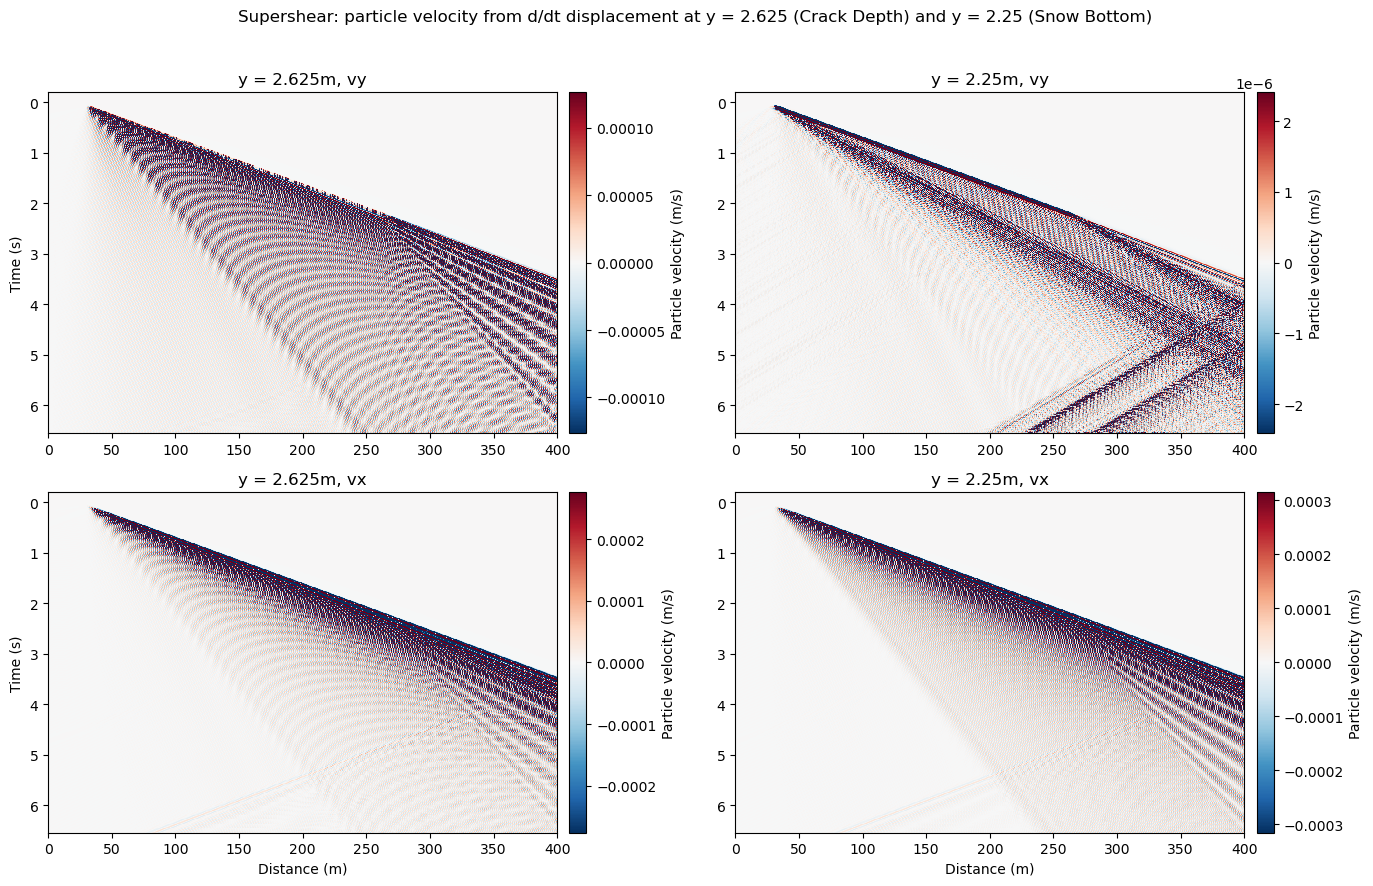

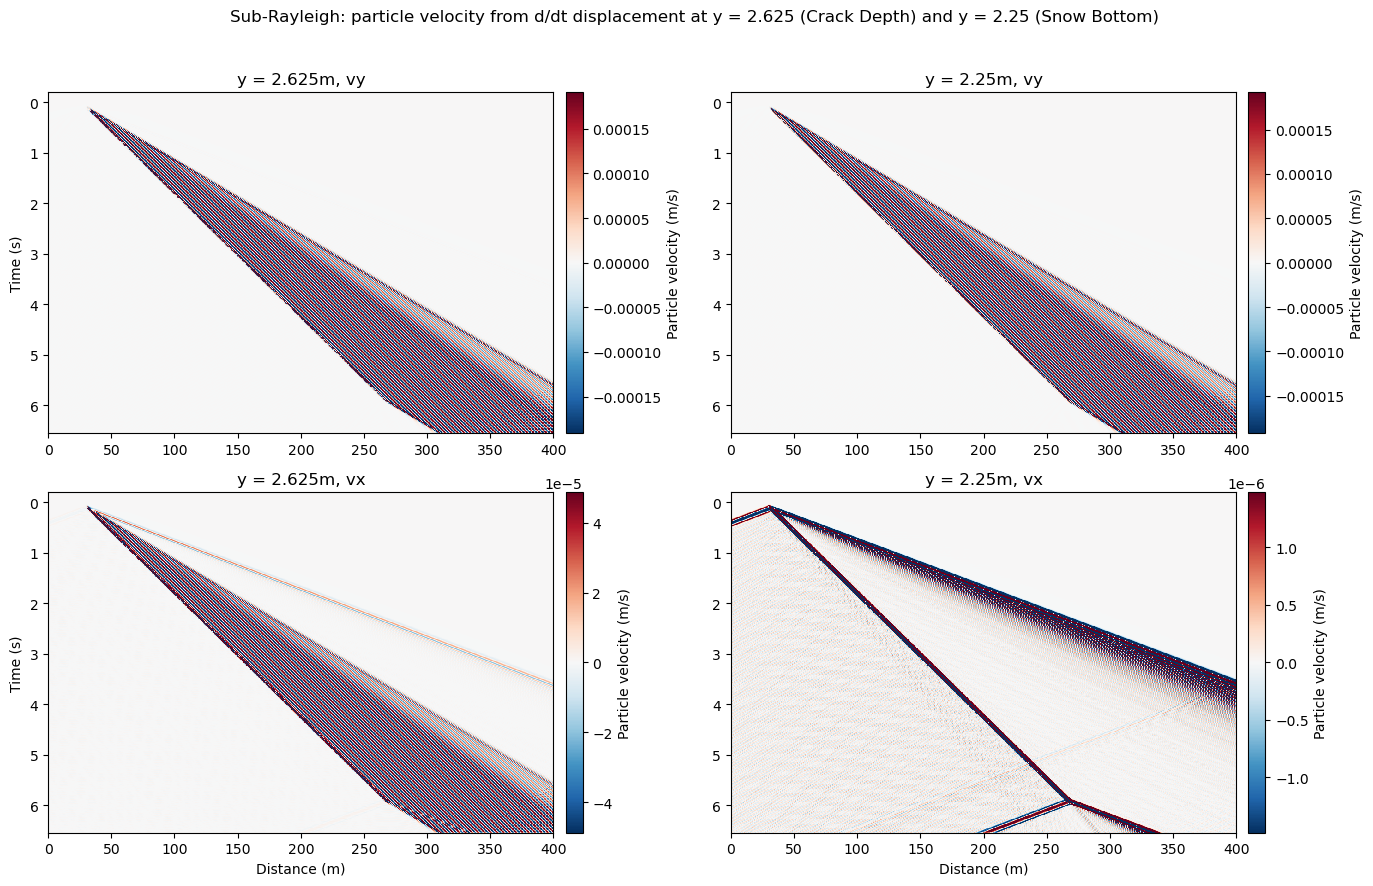

In [23]:


receiver_lines = [2.625, 2.25]

def resolve_names(da):
    coords_set = set(da.coords)
    dims_set = set(da.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={da.dims}, coords={list(da.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name

def extract_section(da, component_index, y_surface):
    x_name, y_name, t_name, c_name, e_name = resolve_names(da)

    sec = da.isel({c_name: component_index}).sel({y_name: y_surface}, method="nearest")

    if e_name is not None and e_name in sec.dims:
        sec = sec.mean(dim=e_name)

    sec = sec.transpose(t_name, x_name)
    return sec, (x_name, y_name, t_name, c_name, e_name)

def plot_case(case_name, da):
    sections = {}

    for y_surface in receiver_lines:
        vx, info = extract_section(da, 0, y_surface)
        vy, _ = extract_section(da, 1, y_surface)

        sections[y_surface] = {
            "vx": vx,
            "vy": vy,
            "info": info,
        }

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False)

    row_specs = [
        ("vy", "Vertical particle velocity from d/dt displacement"),
        ("vx", "Horizontal particle velocity from d/dt displacement"),
    ]

    for col, y_surface in enumerate(receiver_lines):
        vx = sections[y_surface]["vx"]
        vy = sections[y_surface]["vy"]
        x_name, _, t_name, _, _ = sections[y_surface]["info"]

        x_vals = vx[x_name].values
        t_vals = vx[t_name].values

        for row, (label, _) in enumerate(row_specs):
            data = vy.values if label == "vy" else vx.values
            
            # --- ROBUST LOCAL PERCENTILE CLIPPING ---
        
            panel_vmax = np.nanpercentile(np.abs(data), 95)
            
            # Prevent division/scale errors if a panel happens to be completely silent
            if panel_vmax == 0.0:
                panel_vmax = 1.0

            im = axes[row, col].pcolormesh(
                x_vals,
                t_vals,
                data,
                shading="nearest",
                cmap="RdBu_r",
                vmin=-panel_vmax,
                vmax=panel_vmax,
            )
            axes[row, col].invert_yaxis()
            axes[row, col].set_xlim(0, 400)
            axes[row, col].set_ylim(t_vals[-1], t_vals[0])
            axes[row, col].set_title(f"y = {y_surface}m, {label}")
            if col == 0:
                axes[row, col].set_ylabel("Time (s)")
            if row == 1:
                axes[row, col].set_xlabel("Distance (m)")
            cbar = fig.colorbar(im, ax=axes[row, col], pad=0.02)
            cbar.set_label("Particle velocity (m/s)")

    fig.suptitle(
        f"{case_name}: particle velocity from d/dt displacement at y = 2.625 (Crack Depth) and y = 2.25 (Snow Bottom)",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)

# --- Execute Plotting Scripts ---
plot_case("Supershear", super_dis_2d_layered_dt)
plot_case("Sub-Rayleigh", sub_dis_2d_layered_dt)

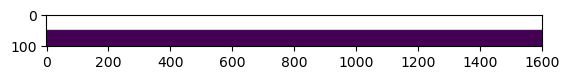

In [24]:
plt.imshow(np.squeeze(super_dis_2d_layered_dt[20,0,:,:]).transpose())
plt.show()

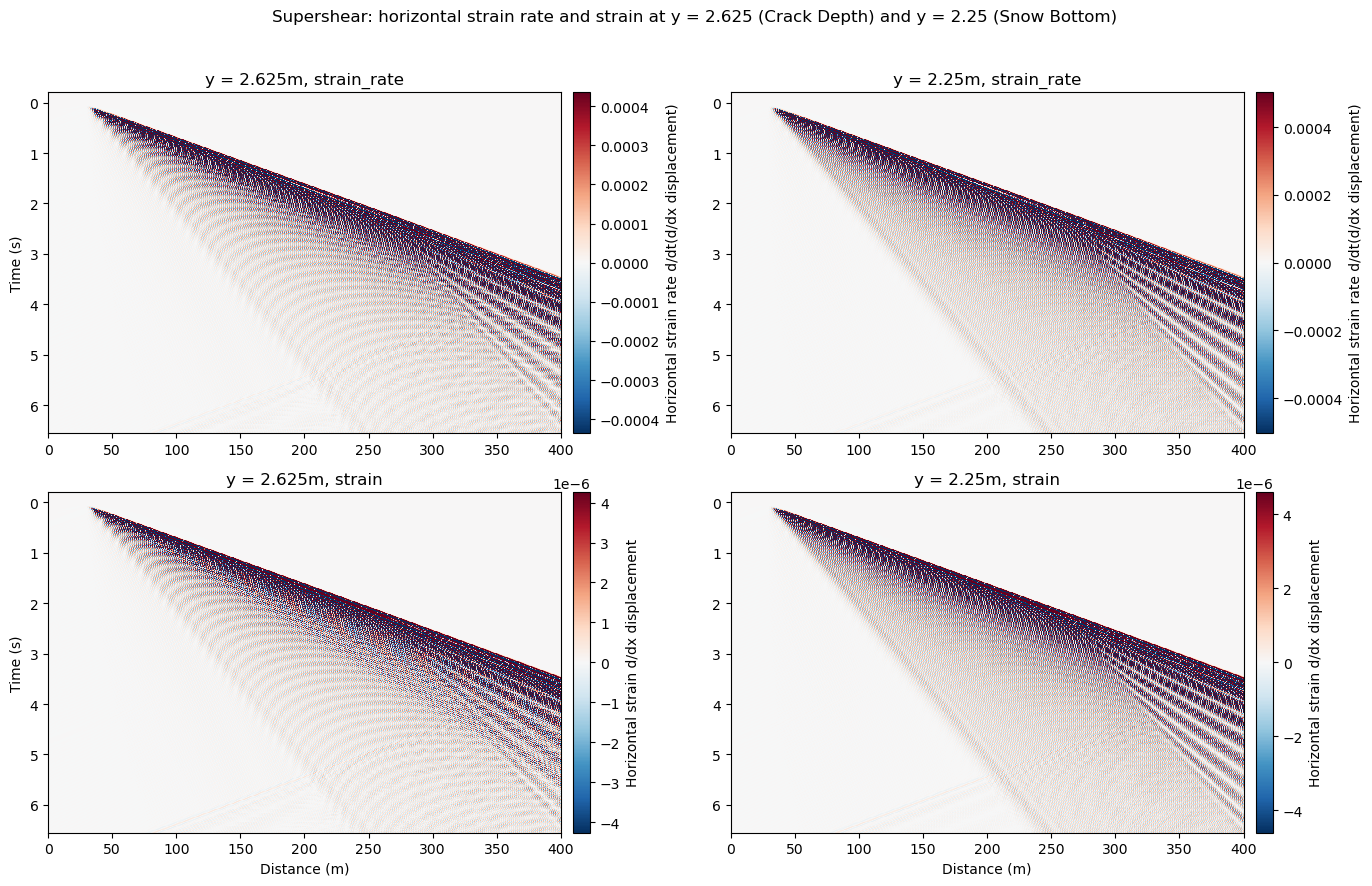

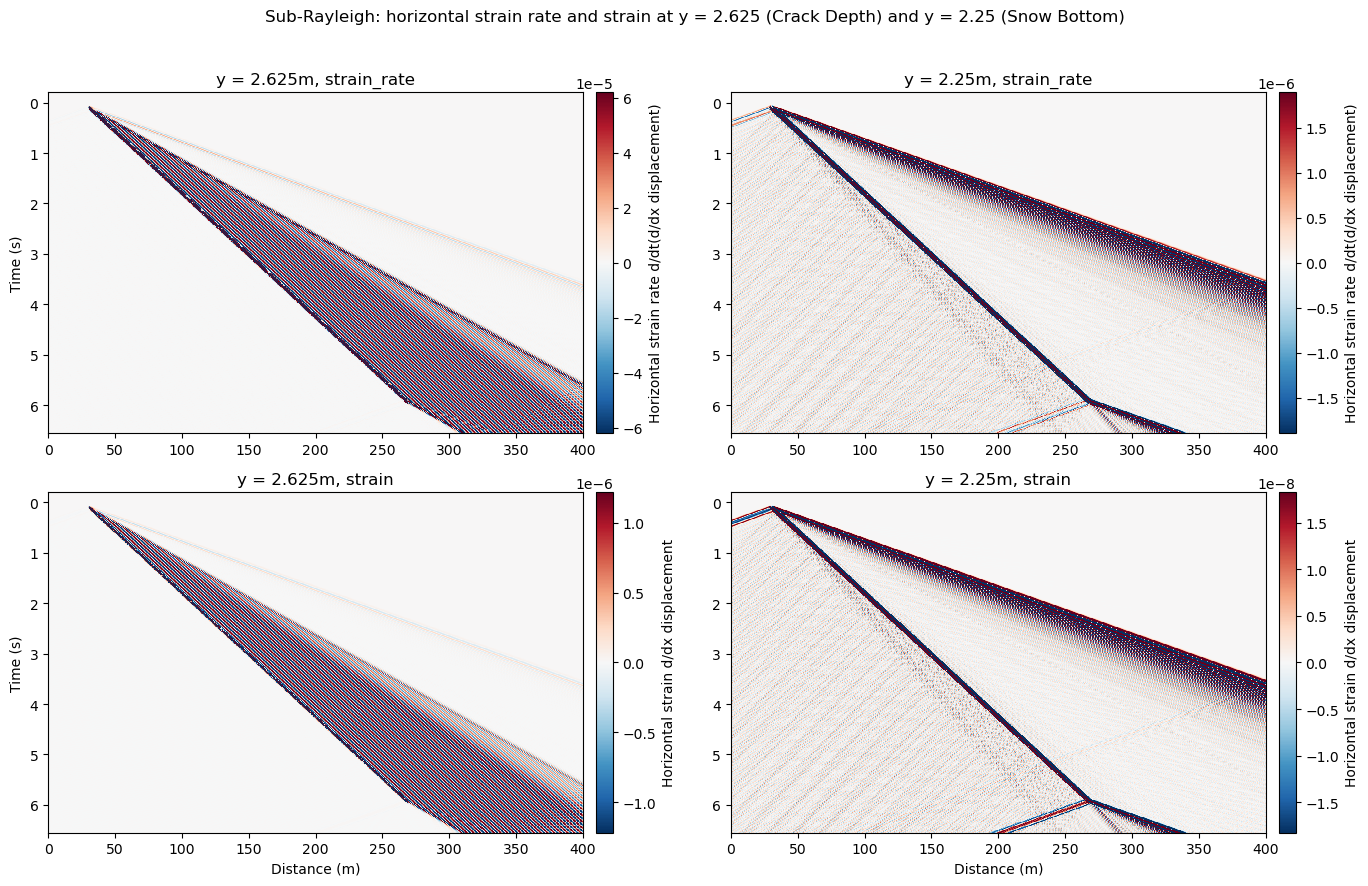

In [25]:
# Plotting horizontal strain rate and horizontal strain for both cases at two receiver depths

receiver_lines = [2.625, 2.25]


def resolve_names(da):
    coords_set = set(da.coords)
    dims_set = set(da.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={da.dims}, coords={list(da.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name


def extract_component_section(da, component_index, y_surface):
    x_name, y_name, t_name, c_name, e_name = resolve_names(da)

    sec = da.isel({c_name: component_index}).sel({y_name: y_surface}, method="nearest")

    if e_name is not None and e_name in sec.dims:
        sec = sec.mean(dim=e_name)

    sec = sec.transpose(t_name, x_name)
    return sec, (x_name, y_name, t_name, c_name, e_name)


def plot_case(case_name, displacement, velocity):
    sections = {}

    displacement_x_name, _, displacement_time_name, _, _ = resolve_names(displacement)
    velocity_x_name, _, velocity_time_name, _, _ = resolve_names(velocity)

    strain_x = displacement.differentiate(displacement_x_name)
    strain_rate_x = strain_x.differentiate(displacement_time_name)
    strain_rate_x_alt = velocity.differentiate(velocity_x_name)

    for y_surface in receiver_lines:
        strain, info = extract_component_section(strain_x, 0, y_surface)
        strain_rate, _ = extract_component_section(strain_rate_x, 0, y_surface)
        strain_rate_alt, _ = extract_component_section(strain_rate_x_alt, 0, y_surface)

        sections[y_surface] = {
            "strain": strain,
            "strain_rate": strain_rate,
            "strain_rate_alt": strain_rate_alt,
            "info": info,
        }

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False)

    row_specs = [
        ("strain_rate", "Horizontal strain rate d/dt(d/dx displacement)"),
        ("strain", "Horizontal strain d/dx displacement"),
    ]

    for col, y_surface in enumerate(receiver_lines):
        strain = sections[y_surface]["strain"]
        strain_rate = sections[y_surface]["strain_rate"]
        strain_rate_alt = sections[y_surface]["strain_rate_alt"]
        x_name, _, t_name, _, _ = sections[y_surface]["info"]

        x_vals = strain[x_name].values
        t_vals = strain[t_name].values

        for row, (label, cbar_label) in enumerate(row_specs):
            data = strain_rate.values if label == "strain_rate" else strain.values
            
            # --- ROBUST LOCAL PERCENTILE CLIPPING ---
            # Calculates the 95th percentile specifically for this local panel slice
            # to prevent high-amplitude source injection artifacts from drowning out everything.
            scale = np.nanpercentile(np.abs(data), 95)
            
            # Fallback to avoid division/scale bugs if data is completely flat
            if scale == 0.0:
                scale = 1.0

            im = axes[row, col].pcolormesh(
                x_vals,
                t_vals,
                data,
                shading="nearest",
                cmap="RdBu_r",
                vmin=-scale,
                vmax=scale,
            )
            axes[row, col].invert_yaxis()
            axes[row, col].set_xlim(0, 400)
            axes[row, col].set_title(f"y = {y_surface}m, {label}")
            if col == 0:
                axes[row, col].set_ylabel("Time (s)")
            if row == 1:
                axes[row, col].set_xlabel("Distance (m)")
            cbar = fig.colorbar(im, ax=axes[row, col], pad=0.02)
            cbar.set_label(cbar_label)

    fig.suptitle(
        f"{case_name}: horizontal strain rate and strain at y = 2.625 (Crack Depth) and y = 2.25 (Snow Bottom)",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# --- Execute Plotting Scripts ---
plot_case("Supershear", super_dis_2d_layered, super_dis_2d_layered_dt)
plot_case("Sub-Rayleigh", sub_dis_2d_layered, sub_dis_2d_layered_dt)

In [26]:
displacement_x_name, _, displacement_time_name, _, _ = resolve_names(super_dis_2d_layered)

In [27]:
super_dis_2d_layered

<xarray.DataArray (t: 760, c: 2, x: 1601, y: 101)> Size: 983MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
          -3.45770786e-07, -3.18639309e-07, -2.89299265e-07],
         [            nan,             nan,             nan, ...,
          -3.32922923e-07, -3.26719544e-07, -3.18851761e-07],
         [            nan,             nan,             nan, ...,
          -2.88175386e-07, -3.12624877e-07, -3.38329187e-07]],

        [[            nan,             nan,             nan, ...,
          -1.67000391e-09, -1.66815584e-09, -1.66614944e-09],
         [            nan,             nan,             nan, ...,
          -2.29417729e-09, -2.31169417e-09, -2.32272401e-09],
         [            nan,             nan,             nan, ...,
          -3.21175930e-09, -3.22518989e-09, -3.22785421e-09],
         ...,
         [            nan,             nan,             nan, ...,
          -6.13425115e-08, -6.13787066e-08, -6.08922832e-08],
         [            nan,             nan,             nan, ...,
          -2.33695772e-07, -2.35188210e-07, -2.35164364e-07],
         [            nan,             nan,             nan, ...,
          -1.69701380e-07, -1.70222691e-07, -1.70439407e-07]]]],
      dtype=float32)
Coordinates:
  * t        (t) float64 6kB -0.2 -0.1911 -0.1822 -0.1733 ... 6.531 6.539 6.548
  * c        (c) int64 16B 0 1
  * x        (x) float64 13kB 0.0 0.25 0.5 0.75 1.0 ... 399.2 399.5 399.8 400.0
  * y        (y) float64 808B 0.0 0.03 0.06 0.09 0.12 ... 2.91 2.94 2.97 3.0

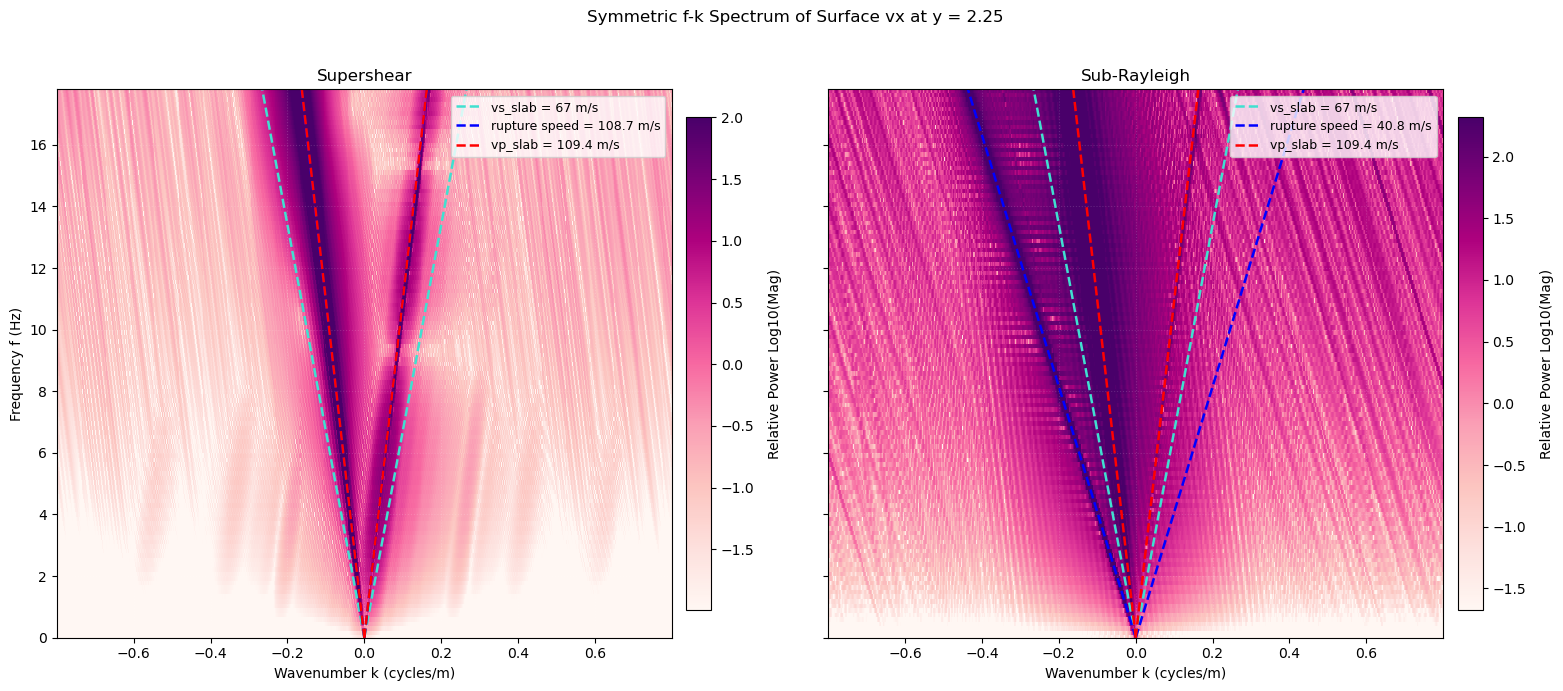

In [28]:
# Frequency domain analysis: f-k analysis with symmetric V-line overlays
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from IPython.display import display

# Use the horizontal velocity component at the snow surface.
y_recv = 2.25   # Snow coordinate target position

super_speed = 1.6*67.9366  # supershear: 1.6*vs, according to trottet et al, 2022
sub_speed = 0.6*67.9366  # sub-rayleigh: 0.6*vs, according to trottet et al, 2022

cases = {
    "Supershear": super_dis_2d_layered_dt,
    "Sub-Rayleigh": sub_dis_2d_layered_dt,
}
rupture_speeds = {
    "Supershear": super_speed,
    "Sub-Rayleigh": sub_speed,
}


def resolve_names(da):
    coords_set = set(da.coords)
    dims_set = set(da.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={da.dims}, coords={list(da.coords)}"
        )

    return x_name, y_name, t_name, c_name


def compute_fk_panel(da, y_surface):
    x_name, y_name, t_name, c_name = resolve_names(da)

    sg = da.sel({y_name: y_surface}, method="nearest").isel({c_name: 0})
    sg = sg.transpose(t_name, x_name)

    t_vals = sg[t_name].values
    x_vals = sg[x_name].values
    data = sg.values

    if data.shape[0] == len(x_vals):
        data = data.T

    nt, nx = data.shape
    dt = float(np.nanmedian(np.diff(t_vals)))
    dx = float(np.nanmedian(np.diff(x_vals)))

    std_per_trace = np.std(data, axis=0, keepdims=True)
    std_per_trace[std_per_trace < 1e-20] = 1.0
    data_normalized = data / std_per_trace

    taper_t = np.hanning(nt)
    taper_x = np.hanning(nx)
    data_tapered = data_normalized * taper_t[:, None] * taper_x[None, :]
    fk = np.fft.fftshift(np.fft.fft2(data_tapered))
    freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
    wns = np.fft.fftshift(np.fft.fftfreq(nx, dx))

    f_pos_mask = freqs >= 0
    fk_pos = fk[f_pos_mask, :]
    f_plot = freqs[f_pos_mask]

    pk = np.log10(np.abs(fk_pos) + 1e-10)
    vmax_pk = np.percentile(pk, 99)
    vmin_pk = vmax_pk - 4

    return {
        "pk": pk,
        "f_plot": f_plot,
        "wns": wns,
        "vmin_pk": vmin_pk,
        "vmax_pk": vmax_pk,
        "k_max": float(np.nanmax(np.abs(wns))),
    }


panels = {case_name: compute_fk_panel(da, y_recv) for case_name, da in cases.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

reference_velocities = [
    ("vs_slab = 67 m/s", 67, "turquoise"),
    ("rupture speed", None, "blue"),
    ("vp_slab = 109.4 m/s", 109.4, "red"),
]

for ax, (case_name, panel) in zip(axes, panels.items()):
    WNS, FREQS = np.meshgrid(panel["wns"], panel["f_plot"])

    mesh = ax.pcolormesh(
        WNS,
        FREQS,
        panel["pk"],
        shading="nearest",
        cmap="RdPu",
        vmin=panel["vmin_pk"],
        vmax=panel["vmax_pk"],
    )

    k_max = panel["k_max"]
    rupture_speed = rupture_speeds[case_name]

    for label, v, col in reference_velocities:
        speed = rupture_speed if v is None else v
        k_right = panel["f_plot"] / speed
        mask_right = np.abs(k_right) <= k_max
        ax.plot(
            k_right[mask_right],
            panel["f_plot"][mask_right],
            color=col,
            lw=1.8,
            linestyle="--",
            label=label if v is not None else f"rupture speed = {speed:.1f} m/s",
        )

        k_left = -panel["f_plot"] / speed
        mask_left = np.abs(k_left) <= k_max
        ax.plot(
            k_left[mask_left],
            panel["f_plot"][mask_left],
            color=col,
            lw=1.8,
            linestyle="--",
        )

    ax.set_xlim(-k_max * 0.4, k_max * 0.4)
    ax.set_ylim(0, 17.8)
    ax.set_xlabel("Wavenumber k (cycles/m)")
    ax.set_title(f"{case_name}")
    ax.grid(True, alpha=0.15, color="white", linestyle=":")
    ax.legend(fontsize=9, loc="upper right")
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.9, pad=0.02)
    cbar.set_label("Relative Power Log10(Mag)", labelpad=10)

axes[0].set_ylabel("Frequency f (Hz)")
fig.suptitle("Symmetric f-k Spectrum of Surface vx at y = 2.25", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
display(fig)
plt.close(fig)

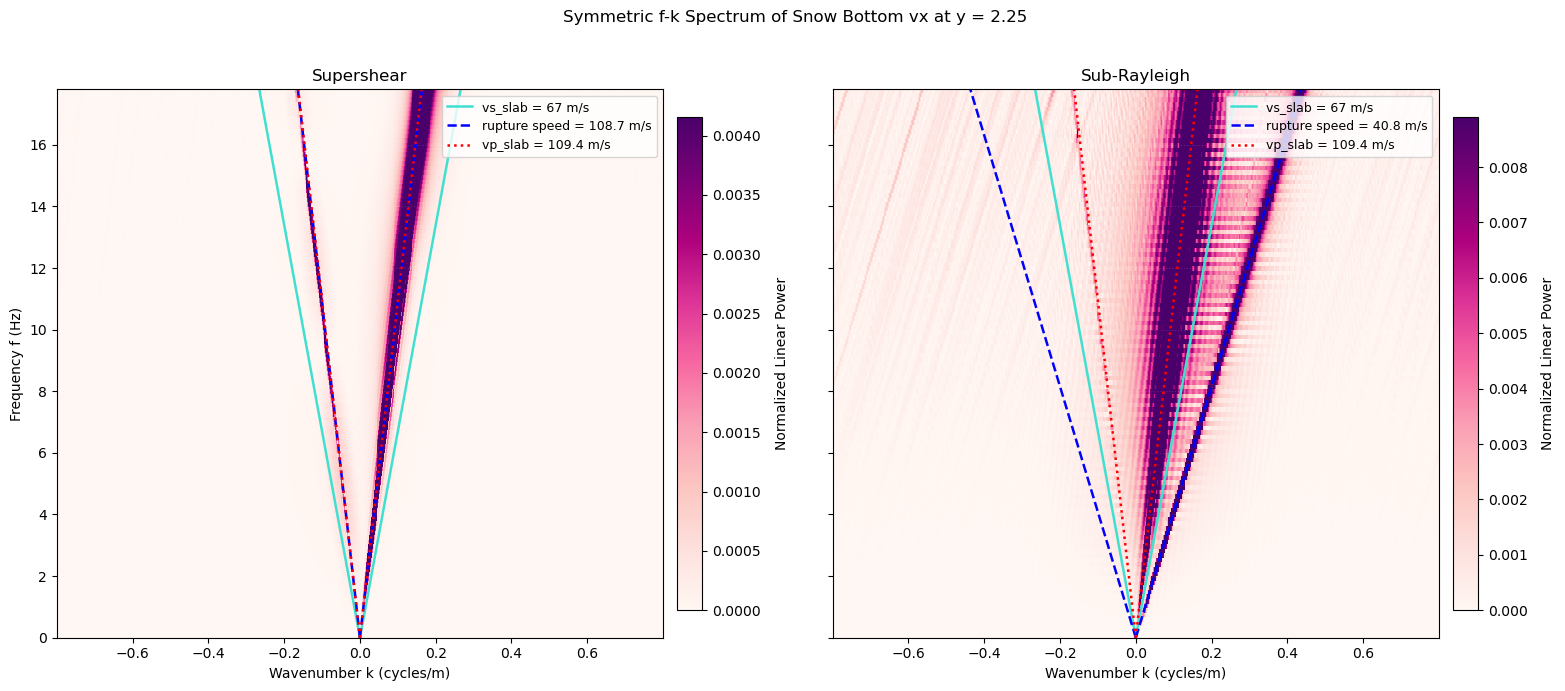

In [29]:
# Use the horizontal velocity component at the snow surface.
y_recv = 2.25   

super_speed = 1.6 * 67.9366  
sub_speed = 0.6 * 67.9366  

cases = {
    "Supershear": super_dis_2d_layered_dt,
    "Sub-Rayleigh": sub_dis_2d_layered_dt,
}
rupture_speeds = {
    "Supershear": super_speed,
    "Sub-Rayleigh": sub_speed,
}

def resolve_names(da):
    coords_set = set(da.coords)
    dims_set = set(da.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError("Could not resolve required dimensions.")

    return x_name, y_name, t_name, c_name

def compute_fk_panel(da, y_surface):
    x_name, y_name, t_name, c_name = resolve_names(da)

    sg = da.sel({y_name: y_surface}, method="nearest").isel({c_name: 0})
    sg = sg.transpose(t_name, x_name)

    t_vals = sg[t_name].values
    x_vals = sg[x_name].values
    data = sg.values

    if data.shape[0] == len(x_vals):
        data = data.T

    nt, nx = data.shape
    dt = float(np.nanmedian(np.diff(t_vals)))
    dx = float(np.nanmedian(np.diff(x_vals)))

    std_per_trace = np.std(data, axis=0, keepdims=True)
    std_per_trace[std_per_trace < 1e-20] = 1.0
    data_normalized = data / std_per_trace

    taper_t = np.hanning(nt)
    taper_x = np.hanning(nx)
    data_tapered = data_normalized * taper_t[:, None] * taper_x[None, :]
    
    # Compute 2D FFT
    fk = np.fft.fftshift(np.fft.fft2(data_tapered))
    freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
    wns = np.fft.fftshift(np.fft.fftfreq(nx, dx))

    # Flip the wavenumber axis to correct the NumPy FFT phase convention
    
    fk = np.fliplr(fk)

    f_pos_mask = freqs >= 0
    fk_pos = fk[f_pos_mask, :]
    f_plot = freqs[f_pos_mask]

    # Linear magnitude linearized by 99th percentile
    mag = np.abs(fk_pos)
    pk = mag / np.max(mag) 
    
    
    vmax_pk = np.percentile(pk, 99) 
    vmin_pk = 0.0 # Linear magnitude starts at 0

    return {
        "pk": pk,
        "f_plot": f_plot,
        "wns": wns,
        "vmin_pk": vmin_pk,
        "vmax_pk": vmax_pk,
        "k_max": float(np.nanmax(np.abs(wns))),
    }

panels = {case_name: compute_fk_panel(da, y_recv) for case_name, da in cases.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)


reference_velocities = [
    ("vs_slab = 67 m/s", 67, "turquoise", "-"),
    ("rupture speed", None, "blue", "--"),
    ("vp_slab = 109.4 m/s", 109.4, "red", ":"),
]

for ax, (case_name, panel) in zip(axes, panels.items()):
    WNS, FREQS = np.meshgrid(panel["wns"], panel["f_plot"])


    mesh = ax.pcolormesh(
        WNS,
        FREQS,
        panel["pk"],
        shading="nearest",
        cmap="RdPu", 
        vmin=panel["vmin_pk"],
        vmax=panel["vmax_pk"],
    )

    k_max = panel["k_max"]
    rupture_speed = rupture_speeds[case_name]

    for label, v, col, ls in reference_velocities:
        speed = rupture_speed if v is None else v
        
        # Right propagating waves
        k_right = panel["f_plot"] / speed
        mask_right = np.abs(k_right) <= k_max
        ax.plot(
            k_right[mask_right],
            panel["f_plot"][mask_right],
            color=col,
            lw=1.8,
            linestyle=ls,
            label=label if v is not None else f"rupture speed = {speed:.1f} m/s",
        )

        # Left propagating waves
        k_left = -panel["f_plot"] / speed
        mask_left = np.abs(k_left) <= k_max
        ax.plot(
            k_left[mask_left],
            panel["f_plot"][mask_left],
            color=col,
            lw=1.8,
            linestyle=ls,
        )

    ax.set_xlim(-k_max * 0.4, k_max * 0.4)
    ax.set_ylim(0, 17.8)
    ax.set_xlabel("Wavenumber k (cycles/m)")
    ax.set_title(f"{case_name}")
    ax.grid(True, alpha=0.15, color="white", linestyle=":")
    ax.legend(fontsize=9, loc="upper right")
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.9, pad=0.02)
    cbar.set_label("Normalized Linear Power", labelpad=10)

axes[0].set_ylabel("Frequency f (Hz)")
fig.suptitle("Symmetric f-k Spectrum of Snow Bottom vx at y = 2.25", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
display(fig)
plt.close(fig)

In [30]:
# pyber, developed by Mondaic
# Copyright (C) 2024, Institute for Geophysics, ETH Zurich
# All rights reserved
"""
The gauge length object.
"""
from __future__ import annotations

import typing

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import scipy.signal


class GaugeLength:
    def __init__(
        self,
        distances_in_m: npt.ArrayLike,
        weights: npt.ArrayLike,
        gl_type: typing.Optional[str] = None,
    ):
        """
        An object representing a gauge length to integrate measurements over.

        Args:
            distances_in_m: Relative distance in meters.
            weights: The weight of the measurement at each distance.
        """
        self.distances_in_m = np.array(distances_in_m, dtype=np.float64)
        self.weights = np.array(weights, dtype=np.float64)
        self.type = gl_type

        if self.distances_in_m.ndim != 1 or self.weights.ndim != 1:
            raise ValueError(
                "Both distances_in_m and weights must be 1-D arrays."
            )

        if self.distances_in_m.shape != self.weights.shape:
            raise ValueError("Distance and weights must have the same shape.")

    def __eq__(self, other):
        if not isinstance(self, type(other)):
            return False
        return np.allclose(
            self.distances_in_m, other.distances_in_m
        ) and np.allclose(self.weights, other.weights)

    def __ne__(self, other):
        return not self == other

    @classmethod
    def single_point(cls) -> GaugeLength:
        """
        Return a gauge length object with a single point and unit weight.
        """
        return cls(distances_in_m=[0.0], weights=[1.0], gl_type="single")

    @classmethod
    def simple_difference(cls, width_in_m: float) -> GaugeLength:
        """
        Return a gauge length object where the starting and end point of the
        gauge length are subtracted from each other.

        Args:
            width_in_m: The total width of the integration points. Half will be
                to the left, and half to the right of the sample point.
        """
        return cls(
            distances_in_m=np.array([-width_in_m / 2.0, width_in_m / 2]),
            weights=np.array([-1.0 / width_in_m, 1.0 / width_in_m]),
            gl_type="diff",
        )

    @classmethod
    def constant(cls, width_in_m: float, n_samples: int) -> GaugeLength:
        """
        Return a gauge length object with constant weights over a given
        distance.

        Args:
            width_in_m: The total width of the integration points. Half will be
                to the left, and half to the right of the sample point.
            n_samples: The number of samples.
        """
        if n_samples == 1:
            return cls.single_point()

        distances_in_m = np.linspace(
            -width_in_m / 2.0, width_in_m / 2.0, n_samples
        )
        weights = np.ones_like(distances_in_m)
        return cls(
            distances_in_m=distances_in_m, weights=weights, gl_type="constant"
        ).normalize()

    @classmethod
    def gaussian(
        cls, width_in_m: float, n_samples: int, std: float
    ) -> GaugeLength:
        """
        Return a gauge length object with weights distributed according to a
        Gaussian around the sample point.

        Args:
            width_in_m: The total width of the integration points. Half will be
                to the left, and half to the right of the sample point.
            n_samples: The number of samples.
            std: The standard deviation of the Gaussian in meters.
        """
        if n_samples == 1:
            return cls.single_point()

        distances_in_m = np.linspace(
            -width_in_m / 2.0, width_in_m / 2.0, n_samples
        )

        dx = distances_in_m[1] - distances_in_m[0]

        weights = scipy.signal.windows.gaussian(
            n_samples, std=std / dx, sym=True
        )
        return cls(
            distances_in_m=distances_in_m, weights=weights, gl_type="gaussian"
        ).normalize()

    def get_integration_points_and_weights(
        self,
    ) -> typing.Tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
        """
        Returns a tuple of integration points and weights to evaluate the
        integral under the curve using the trapezoid rule honoring the
        additional custom weights.
        """
        if len(self.distances_in_m) == 1:
            return (
                np.require(self.distances_in_m.copy(), dtype=np.float64),
                np.require(self.weights.copy(), dtype=np.float64),
            )

        dx = np.diff(self.distances_in_m)
        weights = np.zeros(len(self.distances_in_m), dtype=np.float64)

        # Trapezoid rule, written per integration point.
        weights[:-1] = self.weights[:-1] / 2.0 * dx
        weights[1:] = self.weights[1:] / 2.0 * dx

        return (
            np.require(self.distances_in_m.copy(), dtype=np.float64),
            weights,
        )

    def compute_integral_of_weights(self) -> float:
        """
        Compute the integrated area of the weights. In most cases this should
        likely be 1.
        """
        if len(self.weights) == 1:
            return 1.0
        return (
            self.get_integration_points_and_weights()[1]
            * np.ones_like(self.weights)
        ).sum()

    def normalize(self) -> GaugeLength:
        """
        Normalize the integrated area using the weights.
        """
        return GaugeLength(
            distances_in_m=self.distances_in_m.copy(),
            weights=self.weights / self.compute_integral_of_weights(),
            gl_type=self.type,
        )

    def plot(self):
        """
        Plot the gauge length.
        """
        plt.fill_between(
            x=self.distances_in_m,
            y1=np.zeros_like(self.weights),
            y2=self.weights,
            facecolor="none",
            hatch="///",
            edgecolor="0.7",
        )
        plt.stem(self.distances_in_m, self.weights)
        plt.hlines(y=0, xmin=-100, xmax=100, lw=0.2, color="0.3")
        plt.vlines(x=0, ymin=-100, ymax=100, lw=0.2, color="0.3")

        plt.xlabel("Relative position around sample point [meter]")
        plt.ylabel("Additional weight of each integration point")

        y_buf = 0.25 * self.weights.max()
        plt.ylim(-y_buf, self.weights.max() + y_buf)

        d = np.abs(self.distances_in_m).max()
        if self.distances_in_m.ptp() == 0:
            d = 0.5
        x_buf = d * 0.5
        plt.xlim(-d - x_buf, d + x_buf)

        plt.title(
            f"Gauge length\n{len(self.weights)} integration points, "
            f"Integration area: {self.compute_integral_of_weights():.2f}"
        )
        plt.tight_layout()

        plt.show()


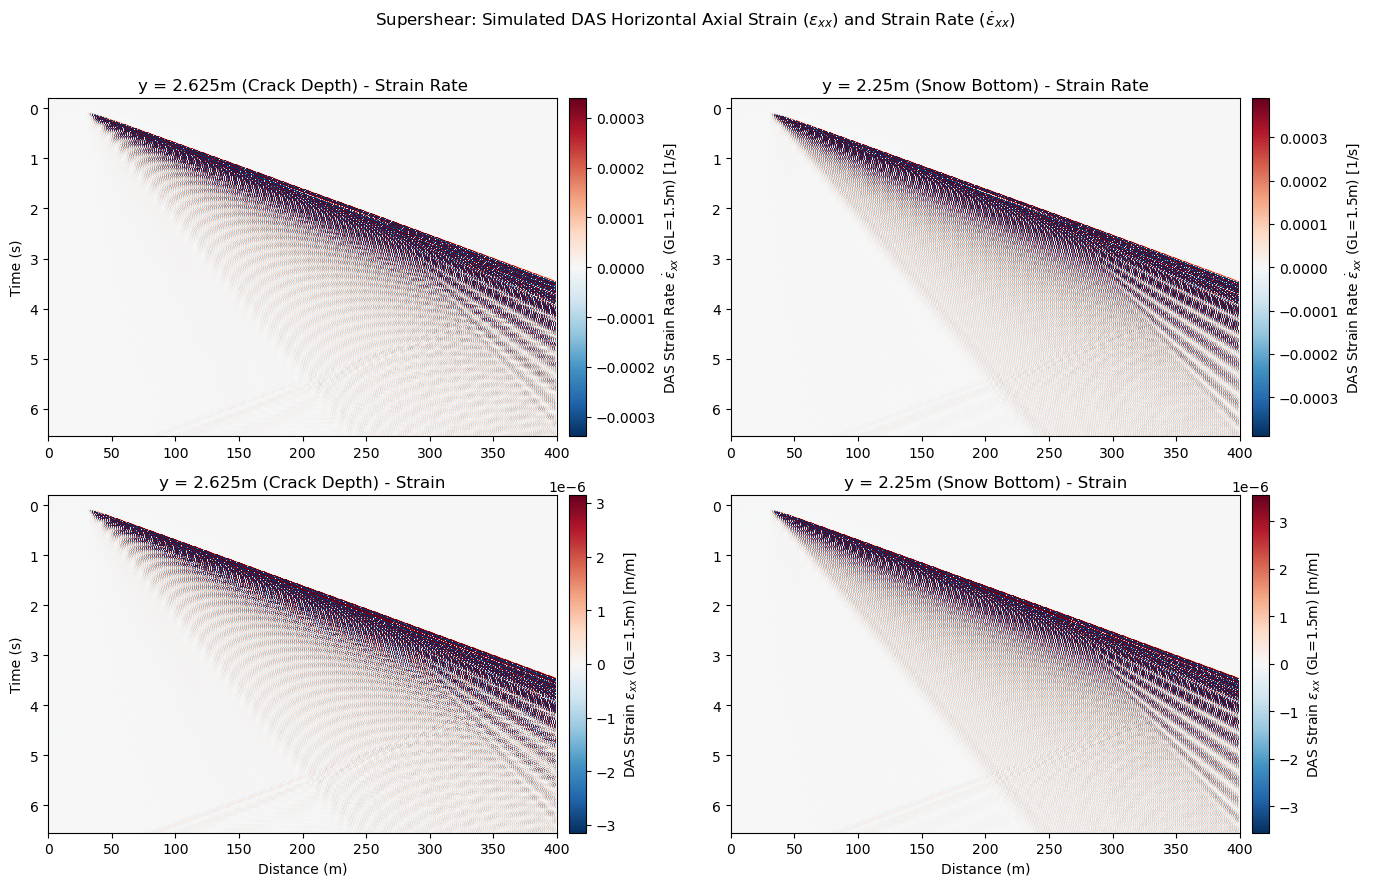

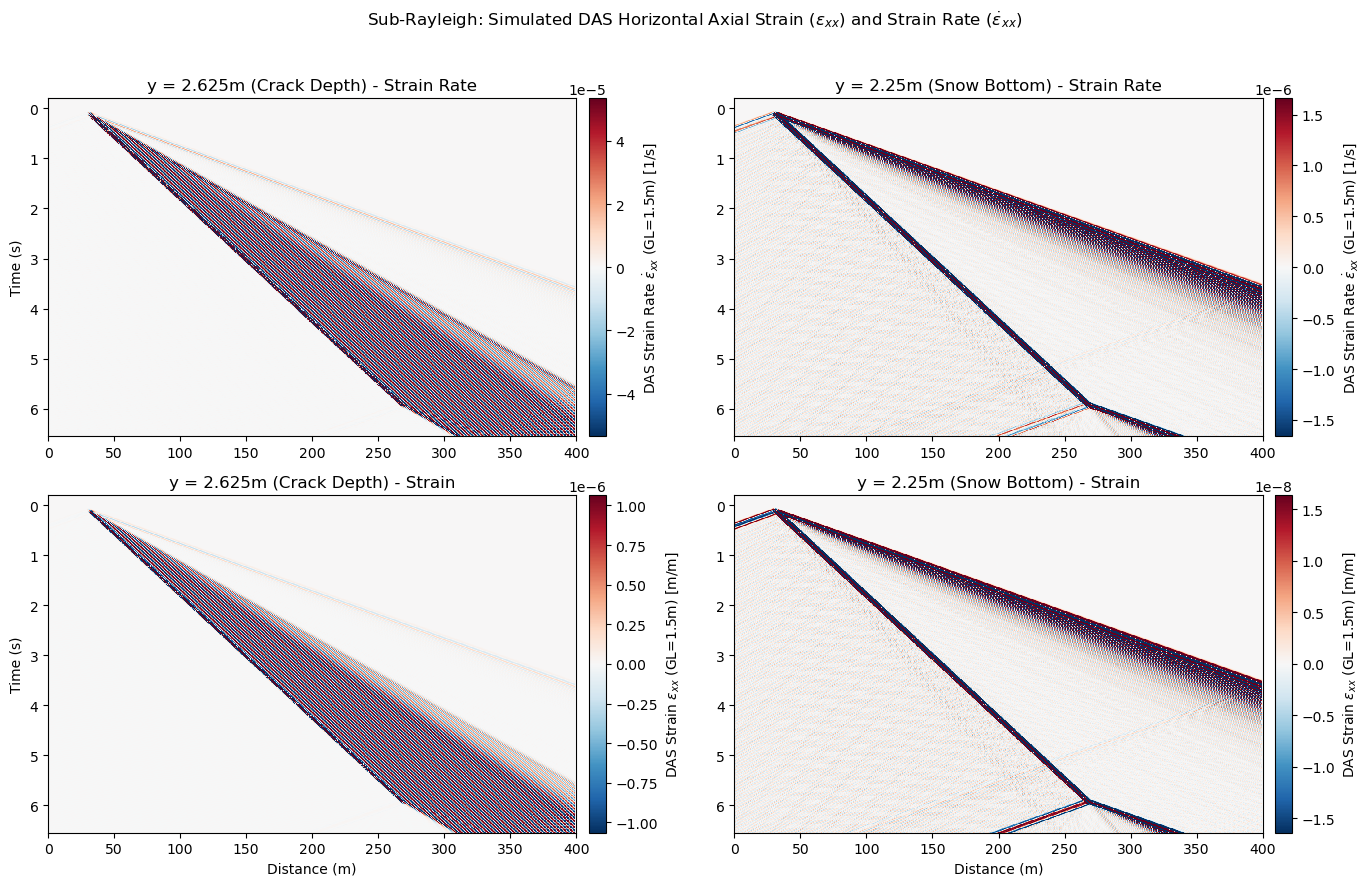

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Define gauge length and elevation coordinate receivers
GAUGE_LENGTH_M = 1.4
receiver_lines = [2.625, 2.25]
depth_labels = {2.625: "Crack Depth", 2.25: "Snow Bottom"}


def resolve_names(da):
    coords_set = set(da.coords)
    dims_set = set(da.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={da.dims}, coords={list(da.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name


def extract_component_section(da, component_index, y_surface):
    x_name, y_name, t_name, c_name, e_name = resolve_names(da)

    sec = da.isel({c_name: component_index}).sel({y_name: y_surface}, method="nearest")

    if e_name is not None and e_name in sec.dims:
        sec = sec.mean(dim=e_name)

    # Transpose to (time, space) for the 2D plot
    sec = sec.transpose(t_name, x_name)
    return sec, (x_name, y_name, t_name, c_name, e_name)


def plot_das_strain_and_rate(case_name, displacement, velocity=None, gauge_length_m=GAUGE_LENGTH_M):
    sections = {}

    displacement_x_name, _, displacement_time_name, _, _ = resolve_names(displacement)
    
    # 1. Figure out the grid spacing (dx)
    x_coords = displacement[displacement_x_name].values
    dx = np.abs(x_coords[1] - x_coords[0])
    
    # 2. Calculate shift in array indices for half the gauge length
    half_shift = max(1, int(np.round((gauge_length_m / 2.0) / dx)))
    actual_gl = (half_shift * 2) * dx  # True GL based on grid snapping
    
    # 3. DIRECT DAS STRAIN: (u(x + L/2) - u(x - L/2)) / L
    u_fwd = displacement.shift({displacement_x_name: -half_shift})
    u_bwd = displacement.shift({displacement_x_name: half_shift})
    das_strain_x = (u_fwd - u_bwd) / actual_gl

    # 4. DIRECT DAS STRAIN RATE: (v(x + L/2) - v(x - L/2)) / L
    if velocity is not None:
        velocity_x_name, _, _, _, _ = resolve_names(velocity)
        v_fwd = velocity.shift({velocity_x_name: -half_shift})
        v_bwd = velocity.shift({velocity_x_name: half_shift})
        das_strain_rate_x = (v_fwd - v_bwd) / actual_gl
    else:
        vel_x = displacement.differentiate(displacement_time_name)
        v_fwd = vel_x.shift({displacement_x_name: -half_shift})
        v_bwd = vel_x.shift({displacement_x_name: half_shift})
        das_strain_rate_x = (v_fwd - v_bwd) / actual_gl

    for y_surface in receiver_lines:
        # Extract the computed true DAS fields
        local_strain, info = extract_component_section(das_strain_x, 0, y_surface)
        local_strain_rate, _ = extract_component_section(das_strain_rate_x, 0, y_surface)
        
        x_name, _, t_name, _, _ = info

        sections[y_surface] = {
            "strain": local_strain,
            "strain_rate": local_strain_rate,
            "x_vals": local_strain[x_name].values,
            "t_vals": local_strain[t_name].values,
        }

    # 2x2 figure grid setup 
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False)

    row_specs = [
        ("strain_rate", f"DAS Strain Rate $\dot{{\epsilon}}_{{xx}}$ (GL={actual_gl:.1f}m) [1/s]"),
        ("strain", f"DAS Strain $\epsilon_{{xx}}$ (GL={actual_gl:.1f}m) [m/m]"),
    ]

    for col, y_surface in enumerate(receiver_lines):
        sec_data = sections[y_surface]
        x_vals = sec_data["x_vals"]
        t_vals = sec_data["t_vals"]

        for row, (data_key, cbar_label) in enumerate(row_specs):
            data = sec_data[data_key].values
            
            # Robust 95th percentile clipping
            scale = np.nanpercentile(np.abs(data), 95)
            if scale == 0.0 or np.isnan(scale):
                scale = 1.0

            im = axes[row, col].pcolormesh(
                x_vals,
                t_vals,
                data,
                shading="nearest",
                cmap="RdBu_r",
                vmin=-scale,
                vmax=scale,
            )
            
            # Clean time axis inversion (t=0 at top)
            axes[row, col].set_ylim(t_vals.max(), t_vals.min())
            axes[row, col].set_xlim(0, 400)
            
            # Format titles and axis labels
            layer_tag = depth_labels.get(y_surface, f"y={y_surface}m")
            axes[row, col].set_title(f"y = {y_surface}m ({layer_tag}) - {data_key.replace('_', ' ').title()}")
            
            if col == 0:
                axes[row, col].set_ylabel("Time (s)")
            if row == 1:
                axes[row, col].set_xlabel("Distance (m)")
                
            cbar = fig.colorbar(im, ax=axes[row, col], pad=0.02)
            cbar.set_label(cbar_label)

    fig.suptitle(
        f"{case_name}: Simulated DAS Horizontal Axial Strain ($\epsilon_{{xx}}$) and Strain Rate ($\dot{{\epsilon}}_{{xx}}$)",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# --- Execution of Plotting Scripts ---
plot_das_strain_and_rate("Supershear", super_dis_2d_layered, super_dis_2d_layered_dt, gauge_length_m=GAUGE_LENGTH_M)
plot_das_strain_and_rate("Sub-Rayleigh", sub_dis_2d_layered, sub_dis_2d_layered_dt, gauge_length_m=GAUGE_LENGTH_M)